# SC-Type Results Scraper

This notebook builds the first experiment summary table for input source type.

The current table includes structural sources (`SC`, `SC_r2t`, `SC+SC_r2t`), the `FC`-input PCA baseline, and the rerun `Krakencoder_precomputed` SC baseline.

Target output:
- one row per `(model, source)`
- a seed-count column like `(n=10)`
- metric columns reported as `mean +/- std` across completed seeds only

If multiple runs exist for the same `(model, source, seed)`, the scraper keeps the run with the best validation metric (default: `val_demeaned_r`) before aggregating across seeds.


In [1]:
import sys
from pathlib import Path
import importlib

import pandas as pd
import wandb
from IPython.display import display

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import results.results_scraper as rs
importlib.reload(rs)

from results.results_scraper import (
    build_experiment_records,
    build_sc_type_summary_table,
    build_status_table,
    load_records_cache,
    plot_source_metric_bars,
    records_to_df,
    save_records_cache,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

wandb.login()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/asr655/.netrc.
wandb: Currently logged in as: asratzan (alexander-ratzan-new-york-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Experiment Spec

Edit this cell to choose which model/source conditions to summarize.
The default setup targets the core source-type comparison table for the linear-family baselines plus the Krakencoder precomputed SC baseline.


In [2]:
MODELS = [
    'CrossModalPCA',
    'CrossModal_PLS_SVD',
    'CrossModal_PCA_PLS',
    'CrossModal_PCA_PLS_learnable',
    'Krakencoder_precomputed',
]

SOURCES = ['SC', 'SC_r2t', 'SC+SC_r2t', 'FC']
SEEDS = list(range(10))

SELECTION_METRIC = 'val_demeaned_r'
SELECTION_MODE = 'max'


SCRAPE_MODE = 'cache'  # 'cache' or 'rescrape'
SCRAPE_CACHE_PATH = REPO_ROOT / 'results' / 'conn2conn' / 'scrape_cache' / 'sc_type_records.json'

METRICS = [
    'pearson',
    'demeaned_pearson',
    'mse',
    'avg_rank',
    'top1_acc',
]

METRIC_LABELS = {
    'pearson': 'corr',
    'demeaned_pearson': 'demeaned_corr',
    'mse': 'mse',
    'avg_rank': 'avg_rank',
    'top1_acc': 'top1_acc',
}

MODELS, SOURCES, SEEDS


(['CrossModalPCA',
  'CrossModal_PLS_SVD',
  'CrossModal_PCA_PLS',
  'CrossModal_PCA_PLS_learnable',
  'Krakencoder_precomputed'],
 ['SC', 'SC_r2t', 'SC+SC_r2t', 'FC'],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## 2. Fetch Seed-Level Best-Trial Records

This pulls the best-trial prod runs from W\&B, then collapses duplicate runs within each `(model, source, seed)` cell by the chosen validation metric.


In [3]:
cache_metadata = {
    'models': MODELS,
    'sources': SOURCES,
    'seeds': SEEDS,
    'selection_metric': SELECTION_METRIC,
    'selection_mode': SELECTION_MODE,
}

if SCRAPE_MODE == 'cache' and SCRAPE_CACHE_PATH.exists():
    records, cache_meta = load_records_cache(SCRAPE_CACHE_PATH)
    print(f'Loaded scrape cache from {SCRAPE_CACHE_PATH}')
    if cache_meta:
        print('Cache metadata:')
        print(cache_meta)
else:
    print('Scraping W&B...')
    records = build_experiment_records(
        models=MODELS,
        sources=SOURCES,
        seeds=SEEDS,
        count_trials=True,
        verbose=True,
        selection_metric=SELECTION_METRIC,
        selection_mode=SELECTION_MODE,
    )
    save_records_cache(records, SCRAPE_CACHE_PATH, metadata=cache_metadata)
    print(f'Saved scrape cache to {SCRAPE_CACHE_PATH}')

n_complete = sum(r.status == 'complete' for r in records)
n_missing = sum(r.status == 'missing' for r in records)
print(f'Total cells: {len(records)}')
print(f'Complete:    {n_complete}')
print(f'Missing:     {n_missing}')


Loaded scrape cache from /scratch/asr655/neuroinformatics/Conn2Conn/results/conn2conn/scrape_cache/sc_type_records.json
Cache metadata:
{'models': ['CrossModalPCA', 'CrossModal_PLS_SVD', 'CrossModal_PCA_PLS', 'CrossModal_PCA_PLS_learnable', 'Krakencoder_precomputed'], 'sources': ['SC', 'SC_r2t', 'SC+SC_r2t', 'FC'], 'seeds': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'selection_metric': 'val_demeaned_r', 'selection_mode': 'max'}
Total cells: 200
Complete:    120
Missing:     80


## 3. Early Checks

These are the user-facing diagnostics before the final summary table:
- completion status by `(model, source, seed)`
- per-seed tune-trial counts for completed runs
- the selected run metadata per seed-level cell


In [4]:
status_table = build_status_table(records)
display(status_table)

seed_df = records_to_df(records).sort_values(['model', 'source', 'seed']).reset_index(drop=True)
summary_cols = [
    'model',
    'source',
    'seed',
    'status',
    'n_tune_trials',
    'wandb_run_name',
    'val_demeaned_r',
    'test_demeaned_pearson',
    'test_pearson',
    'test_mse',
    'test_avg_rank',
    'test_top1_acc',
]
summary_cols = [c for c in summary_cols if c in seed_df.columns]
display(seed_df[summary_cols])


source                               FC                                                                                                       SC                                                  \
seed                                  0          1          2          3          4          5          6          7          8          9     0     1     2     3     4     5     6     7     8   
model                                                                                                                                                                                              
CrossModalPCA                       ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6   
CrossModal_PCA_PLS            ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✓ 24  ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16   
CrossModal_PCA_PLS_learnable  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30   
CrossModal_PLS_SVD            ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12   
Krakencoder_precomputed       ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING   ✓ 0   ✓ 0   ✓ 0   ✓ 0   ✓ 0   ✓ 0   ✓ 0   ✓ 0   ✓ 0   

source                              SC+SC_r2t                                                                                                        SC_r2t                                   \
seed                             9          0          1          2          3          4          5          6          7          8          9          0          1          2          3   
model                                                                                                                                                                                          
CrossModalPCA                  ✓ 6  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING        ✓ 6        ✓ 6        ✓ 6        ✓ 6   
CrossModal_PCA_PLS            ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16   
CrossModal_PCA_PLS_learnable  ✓ 30       ✓ 24       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30   
CrossModal_PLS_SVD            ✓ 12  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING       ✓ 12       ✓ 12       ✓ 12       ✓ 12   
Krakencoder_precomputed        ✓ 0  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING   

source                                                                                          
seed                                  4          5          6          7          8          9  
model                                                                                           
CrossModalPCA                       ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6        ✓ 6  
CrossModal_PCA_PLS                 ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16       ✓ 16  
CrossModal_PCA_PLS_learnable       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30       ✓ 30  
CrossModal_PLS_SVD                 ✓ 12       ✓ 12       ✓ 12       ✓ 12       ✓ 12       ✓ 12  
Krakencoder_precomputed       ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING  ✗ MISSING

,model,source,seed,status,n_tune_trials,wandb_run_name,val_demeaned_r,test_demeaned_pearson,test_pearson,test_mse,test_avg_rank,test_top1_acc
0,CrossModalPCA,FC,0,complete,6,eaaff_best,0.7135,0.7056,0.9213,0.0065,1.0000,1.0000
1,CrossModalPCA,FC,1,complete,6,06843_best,0.7106,0.7118,0.9190,0.0066,1.0000,1.0000
2,CrossModalPCA,FC,2,complete,6,f50c2_best,0.6632,0.6760,0.9130,0.0072,1.0000,1.0000
3,CrossModalPCA,FC,3,complete,6,04bdc_best,0.6273,0.6305,0.9012,0.0079,1.0000,1.0000
4,CrossModalPCA,FC,4,complete,6,020a1_best,0.6790,0.6727,0.9131,0.0074,1.0000,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Krakencoder_precomputed,SC_r2t,5,missing,0,None,NaN,NaN,NaN,NaN,NaN,NaN
196,Krakencoder_precomputed,SC_r2t,6,missing,0,None,NaN,NaN,NaN,NaN,NaN,NaN
197,Krakencoder_precomputed,SC_r2t,7,missing,0,None,NaN,NaN,NaN,NaN,NaN,NaN
198,Krakencoder_precomputed,SC_r2t,8,missing,0,None,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
seed_df[summary_cols].tail(50)

,model,source,seed,status,n_tune_trials,wandb_run_name,val_demeaned_r,test_demeaned_pearson,test_pearson,test_mse,test_avg_rank,test_top1_acc
150,CrossModal_PLS_SVD,SC_r2t,0,complete,12,a7312_best,0.0219,0.0401,0.7796,0.0184,0.5882,0.0154
151,CrossModal_PLS_SVD,SC_r2t,1,complete,12,59f9b_best,0.0751,0.0293,0.8233,0.0144,0.5712,0.0359
152,CrossModal_PLS_SVD,SC_r2t,2,complete,12,fdc96_best,0.0505,0.0432,0.8340,0.0139,0.5694,0.0103
153,CrossModal_PLS_SVD,SC_r2t,3,complete,12,ed38c_best,0.0679,0.0500,0.8241,0.0144,0.6199,0.0308
154,CrossModal_PLS_SVD,SC_r2t,4,complete,12,0d4e5_best,0.0693,0.0514,0.8357,0.0140,0.5684,0.0154
155,CrossModal_PLS_SVD,SC_r2t,5,complete,12,0182c_best,0.0652,0.0505,0.8261,0.0147,0.6292,0.0205
156,CrossModal_PLS_SVD,SC_r2t,6,complete,12,0e7bd_best,0.0861,0.0130,0.8348,0.0139,0.5406,0.0205
157,CrossModal_PLS_SVD,SC_r2t,7,complete,12,7f928_best,0.0677,0.0346,0.8136,0.0153,0.5969,0.0308
158,CrossModal_PLS_SVD,SC_r2t,8,complete,12,68a54_best,0.0513,0.0322,0.7819,0.0187,0.5957,0.0308
159,CrossModal_PLS_SVD,SC_r2t,9,complete,12,d9d2e_best,0.0379,0.0404,0.8207,0.0149,0.5963,0.0306


In [6]:
trial_count_table = (
    seed_df.assign(
        trial_display=seed_df.apply(
            lambda row: row['n_tune_trials'] if row['status'] == 'complete' else '',
            axis=1,
        )
    )
    .pivot_table(
        index=['model', 'source'],
        columns='seed',
        values='trial_display',
        aggfunc='first',
    )
)

print('Tune trials for the selected run in each completed seed cell')
display(trial_count_table)


Tune trials for the selected run in each completed seed cell


seed                                     0   1   2   3   4   5   6   7   8   9
model                        source                                           
CrossModalPCA                FC          6   6   6   6   6   6   6   6   6   6
                             SC          6   6   6   6   6   6   6   6   6   6
                             SC+SC_r2t                                        
                             SC_r2t      6   6   6   6   6   6   6   6   6   6
CrossModal_PCA_PLS           FC                                               
                             SC         24  16  16  16  16  16  16  16  16  16
                             SC+SC_r2t  16  16  16  16  16  16  16  16  16  16
                             SC_r2t     16  16  16  16  16  16  16  16  16  16
CrossModal_PCA_PLS_learnable FC                                               
                             SC         30  30  30  30  30  30  30  30  30  30
                             SC+SC_r2t  24  30  30  30  30  30  30  30  30  30
                             SC_r2t     30  30  30  30  30  30  30  30  30  30
CrossModal_PLS_SVD           FC                                               
                             SC         12  12  12  12  12  12  12  12  12  12
                             SC+SC_r2t                                        
                             SC_r2t     12  12  12  12  12  12  12  12  12  12
Krakencoder_precomputed      FC                                               
                             SC          0   0   0   0   0   0   0   0   0   0
                             SC+SC_r2t                                        
                             SC_r2t

## 4. SC-Type Summary Table

This is the core table for experiment 1.
Each row is one `(model, source)` condition, and the metrics are aggregated across the completed seeds only.


In [7]:
sc_type_table = build_sc_type_summary_table(
    records=records,
    models=MODELS,
    sources=SOURCES,
    metrics=METRICS,
    metric_labels=METRIC_LABELS,
    seeds=SEEDS,
    count_col='seeds',
    n_label='n',
)

display(sc_type_table)


,model,source,seeds,corr,demeaned_corr,mse,avg_rank,top1_acc
0,CrossModalPCA,SC,(n=10),0.8177 +/- 0.0104,0.0116 +/- 0.0080,0.0151 +/- 0.0009,0.5220 +/- 0.0162,0.0097 +/- 0.0081
1,CrossModalPCA,SC_r2t,(n=10),0.7803 +/- 0.0300,0.0032 +/- 0.0093,0.0184 +/- 0.0028,0.5075 +/- 0.0211,0.0051 +/- 0.0040
2,CrossModalPCA,SC+SC_r2t,,,,,,
3,CrossModalPCA,FC,(n=10),0.9164 +/- 0.0063,0.6914 +/- 0.0258,0.0069 +/- 0.0005,1.0000 +/- 0.0000,1.0000 +/- 0.0000
4,CrossModal_PLS_SVD,SC,(n=10),0.8228 +/- 0.0111,0.0727 +/- 0.0139,0.0148 +/- 0.0009,0.6525 +/- 0.0368,0.0354 +/- 0.0128
5,CrossModal_PLS_SVD,SC_r2t,(n=10),0.8174 +/- 0.0195,0.0385 +/- 0.0112,0.0152 +/- 0.0017,0.5876 +/- 0.0249,0.0241 +/- 0.0083
6,CrossModal_PLS_SVD,SC+SC_r2t,,,,,,
7,CrossModal_PLS_SVD,FC,,,,,,
8,CrossModal_PCA_PLS,SC,(n=10),0.8344 +/- 0.0065,0.0904 +/- 0.0101,0.0138 +/- 0.0004,0.7037 +/- 0.0240,0.0338 +/- 0.0134
9,CrossModal_PCA_PLS,SC_r2t,(n=10),0.8338 +/- 0.0048,0.0476 +/- 0.0072,0.0138 +/- 0.0003,0.6128 +/- 0.0177,0.0164 +/- 0.0088


In [8]:
# Optional: export the table for downstream plotting / manuscript prep.
# out_path = REPO_ROOT / 'results' / 'conn2conn' / 'sc_type_summary_table.csv'
# out_path.parent.mkdir(parents=True, exist_ok=True)
# sc_type_table.to_csv(out_path, index=False)
# print(f'Saved to {out_path}')


## 5. Bar Charts

These model-colored bars visualize any scraped test metric across the selected model/source conditions.

- each model has one bar, colored consistently with the scatter plots
- when multiple input sources are included, the source conditions are overlaid as markers
  - `SC` = circle
  - `SC_r2t` = star
  - `SC+SC_r2t` = triangle
  - `FC` = square
- optional oracle and null baselines are drawn as dashed horizontal reference lines
- by default those reference lines come from `CrossModalPCA`
  - `FC` input = oracle line
  - `SC` input = null line


In [9]:
import results.results_scraper as rs
importlib.reload(rs)

from results.results_scraper import *

Pearson comparisons SC only

In [10]:
PLOT_MODELS = [
    #"CrossModalPCA",
    "CrossModal_PLS_SVD",
    "CrossModal_PCA_PLS",
    "CrossModal_PCA_PLS_learnable",
    "Krakencoder_precomputed",
]

SOURCES=["SC"] #, "SC_r2t", "SC+SC_r2t"]


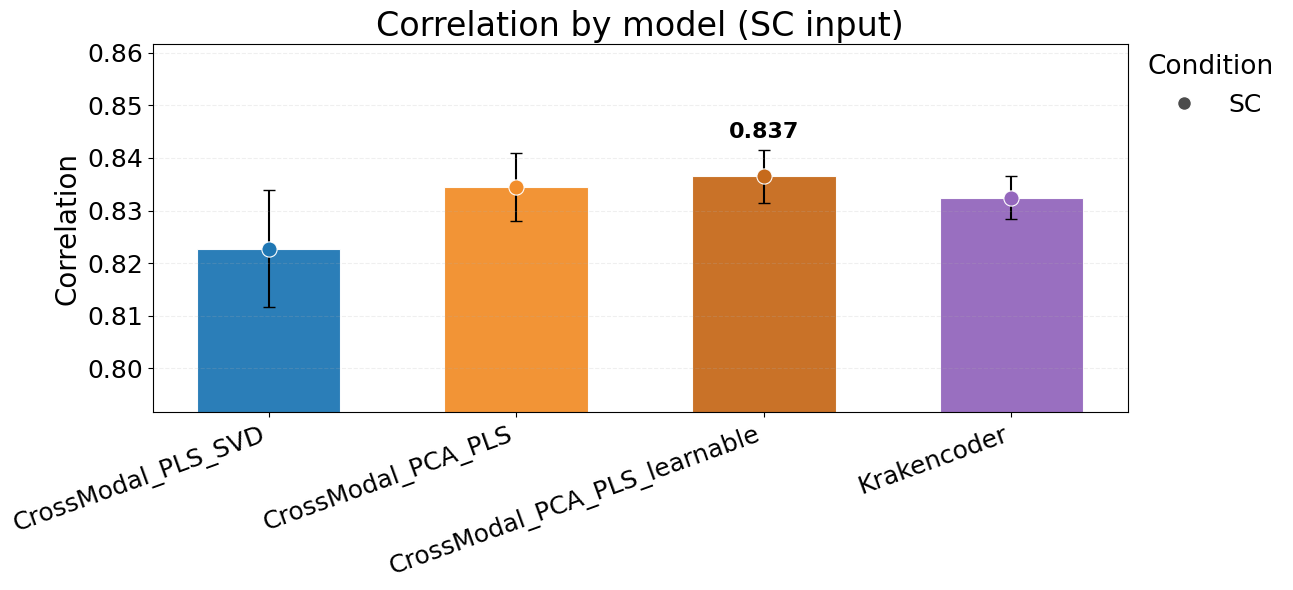

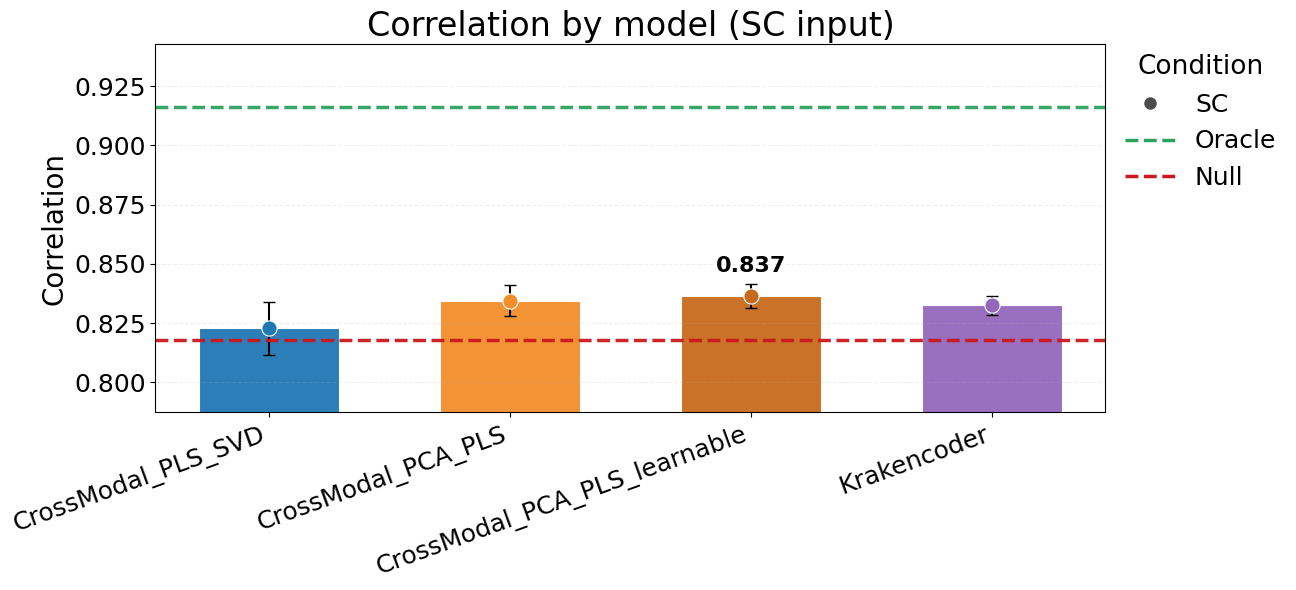

In [11]:
# metric options: pearson, demeaned_pearson, mse, avg_rank, top1_acc
PLOT_METRIC = "pearson"

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=False,
    annotate_best=True,
)

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=True,
    annotate_best=True,
)


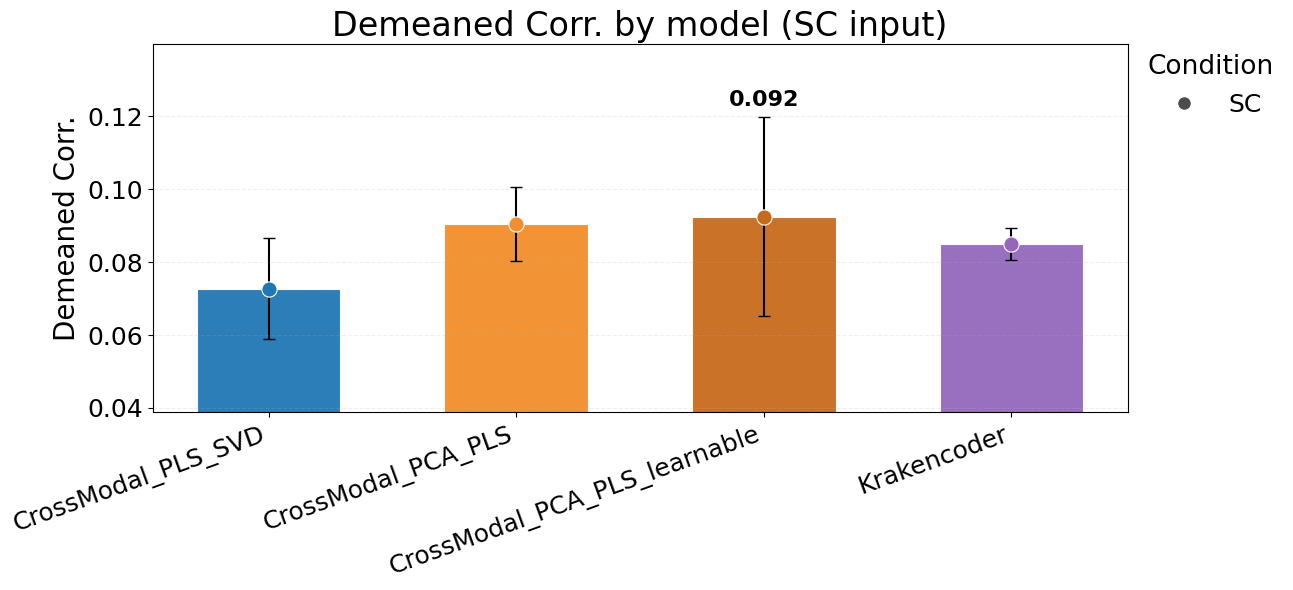

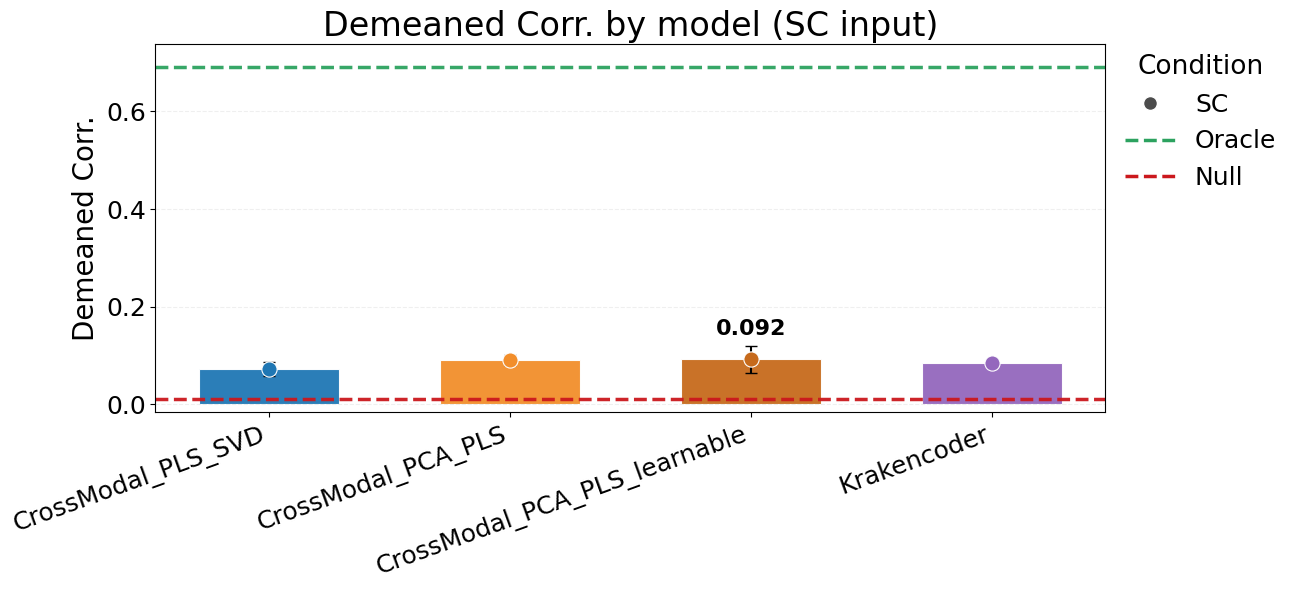

In [12]:
# metric options: pearson, demeaned_pearson, mse, avg_rank, top1_acc
PLOT_METRIC = "demeaned_pearson"

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=False,
    annotate_best=True,
)

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=True,
    annotate_best=True,
)


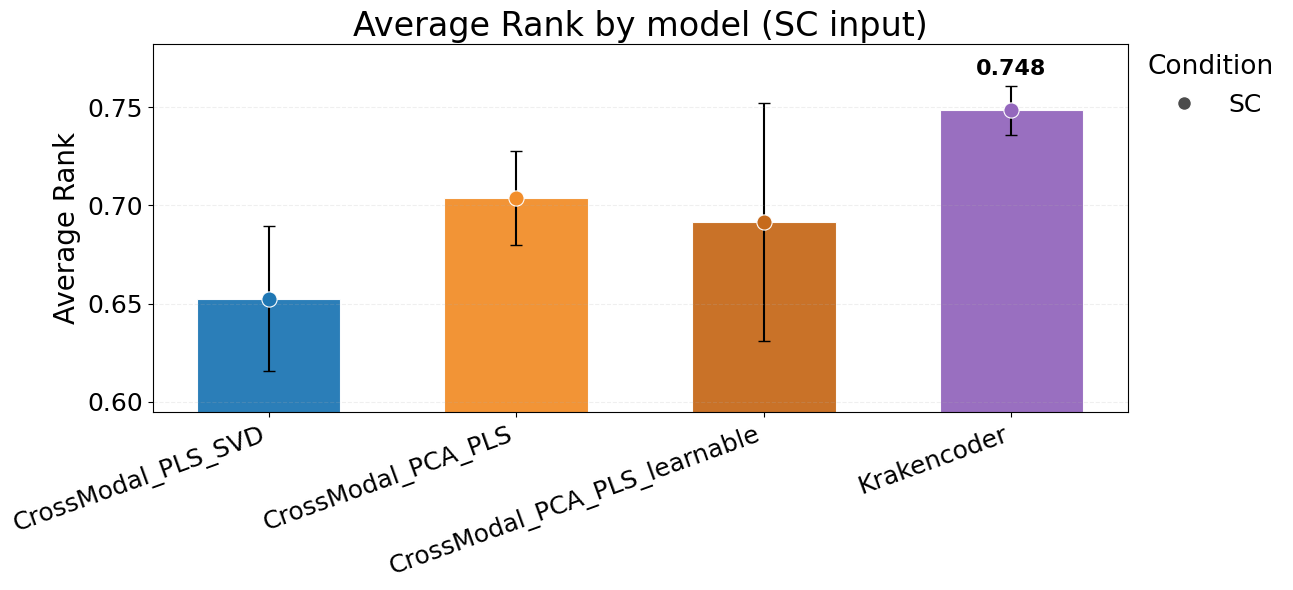

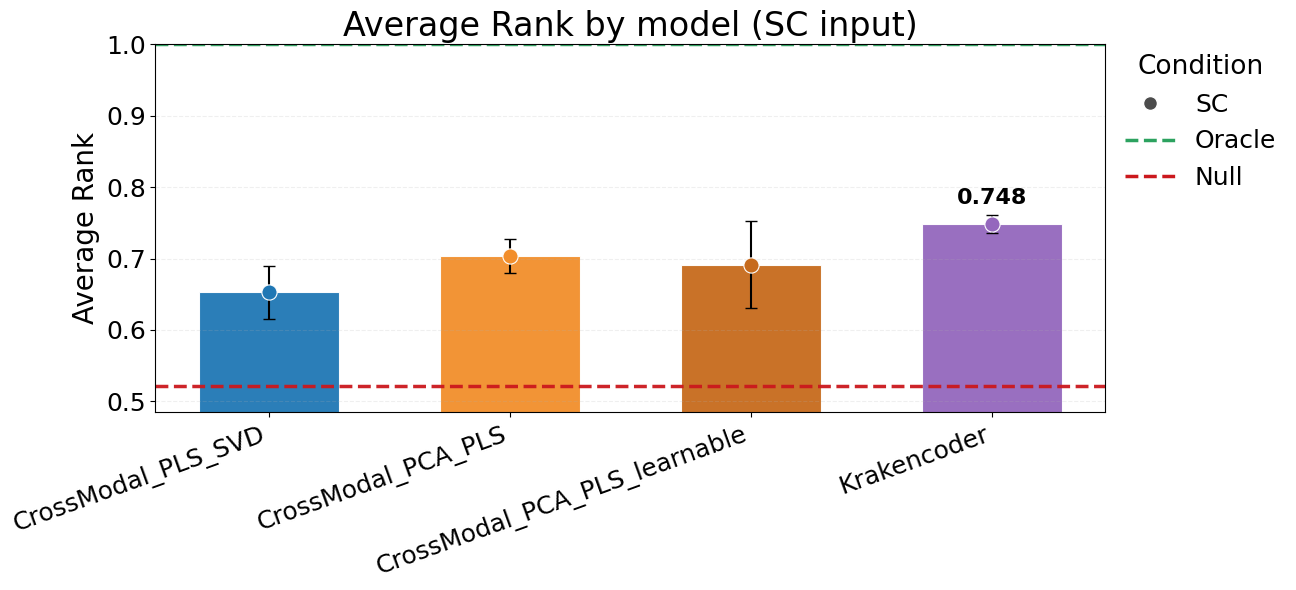

In [13]:
# metric options: pearson, demeaned_pearson, mse, avg_rank, top1_acc
PLOT_METRIC = "avg_rank"

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=False,
    annotate_best=True,
)

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=True,
    annotate_best=True,
)


In [14]:
PLOT_MODELS = [
    #"CrossModalPCA",
    "CrossModal_PLS_SVD",
    "CrossModal_PCA_PLS",
    "CrossModal_PCA_PLS_learnable",
    "Krakencoder_precomputed",
]

SOURCES=["SC", "SC_r2t", "SC+SC_r2t"]

Multimodal

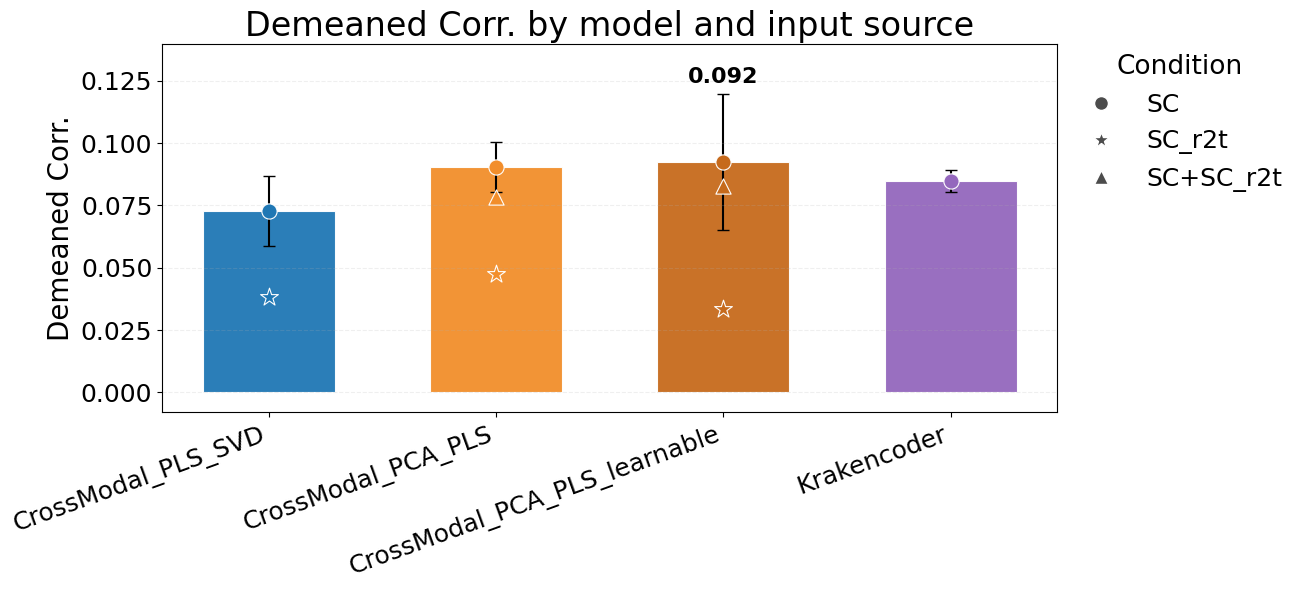

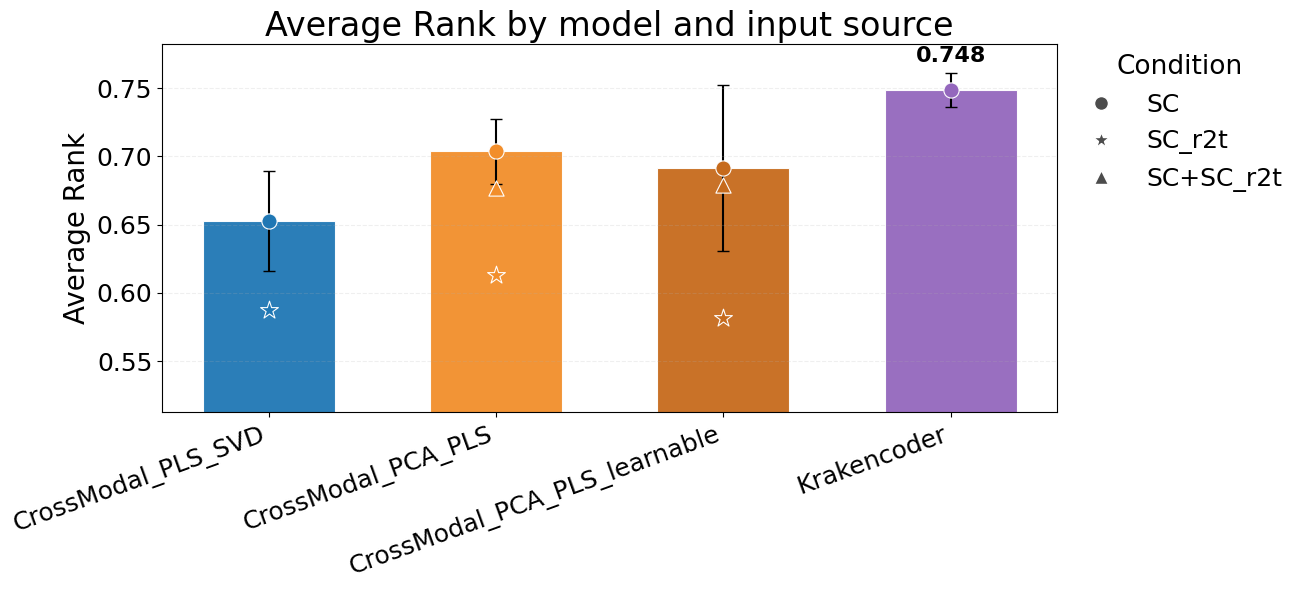

In [15]:
PLOT_METRIC = "demeaned_pearson"

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=False,
    annotate_best=True,
)

PLOT_METRIC = "avg_rank"

fig, ax, plot_df = plot_source_metric_bars(
    records=records,
    models=PLOT_MODELS,
    metric=PLOT_METRIC,
    seeds=SEEDS,
    sources=SOURCES,
    include_reference_lines=False,
    annotate_best=True,
)

Scatter model

In [16]:
import results.results_scraper as rs
importlib.reload(rs)

from results.results_scraper import *

,label,model,source,kind,x_mean,y_mean,x_std,y_std,n,color,marker
0,CrossModal_PLS_SVD,CrossModal_PLS_SVD,SC,model,0.6525,0.0727,0.0368,0.0139,10,#1F77B4,o
1,CrossModal_PCA_PLS,CrossModal_PCA_PLS,SC,model,0.7037,0.0904,0.0240,0.0101,10,#F28E2B,o
2,CrossModal_PCA_PLS_learnable,CrossModal_PCA_PLS_learnable,SC,model,0.6915,0.0924,0.0608,0.0272,10,#C66A1C,o
3,Krakencoder,Krakencoder_precomputed,SC,model,0.7485,0.0850,0.0124,0.0045,10,#9467BD,o


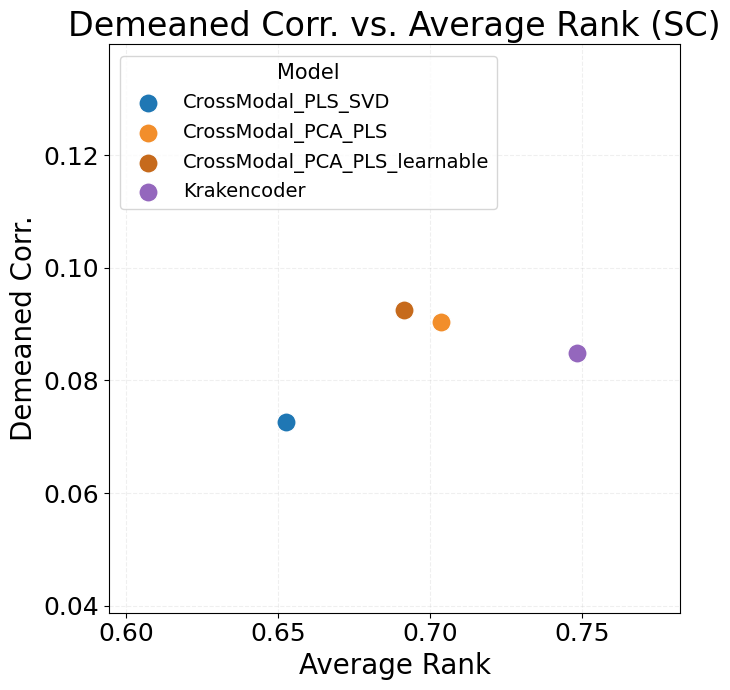

In [17]:
SCATTER_MODELS = [
    "CrossModal_PLS_SVD",
    "CrossModal_PCA_PLS",
    "CrossModal_PCA_PLS_learnable",
    "Krakencoder_precomputed",
]

fig, ax, plot_df = plot_model_metric_scatter(
    records=records,
    models=SCATTER_MODELS,
    source="SC",
    x_metric="avg_rank",
    y_metric="demeaned_pearson",
    seeds=SEEDS,
    include_reference_points=False,
)

plot_df
